In [8]:
!pip install gdown
import gdown
import zipfile
import os
file_id = '1219EeGE1XTJVXYaulynJSa3BXGsbNCLx'
url = f'https://drive.google.com/uc?id={file_id}'
output = 'chest_xray.zip'
gdown.download(url, output, quiet=False)
with zipfile.ZipFile(output, 'r') as zip_ref:
    zip_ref.extractall('/content/pneumonia_dataset')

print("done :3 ")

Downloading...
From (original): https://drive.google.com/uc?id=1219EeGE1XTJVXYaulynJSa3BXGsbNCLx
From (redirected): https://drive.google.com/uc?id=1219EeGE1XTJVXYaulynJSa3BXGsbNCLx&confirm=t&uuid=c9eadee6-9bfd-48bf-92f4-fa6924d20848
To: /content/chest_xray.zip
100%|██████████| 1.23G/1.23G [00:08<00:00, 141MB/s]


done :3 


In [2]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

#actual folders
base_dir = '/content/pneumonia_dataset'
#chest_xray folder
if 'chest_xray' in os.listdir(base_dir):
    base_dir = os.path.join(base_dir, 'chest_xray')

# paths actual location
train_dir = os.path.join(base_dir, 'train')
test_dir = os.path.join(base_dir, 'test')
val_dir = os.path.join(base_dir, 'val')

print(f"Checking paths:\nTrain: {train_dir}\nTest: {test_dir}\nVal: {val_dir}")

#augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

#dataset load
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

val_generator = test_datagen.flow_from_directory(
    val_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

Checking paths:
Train: /content/pneumonia_dataset/train
Test: /content/pneumonia_dataset/test
Val: /content/pneumonia_dataset/val
Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    #Convolutional 1
    Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D(2, 2),
    #convolutional 2
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    #Convolutional 3
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    # Flattening,Dense layer
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [4]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 79s 445ms/step - accuracy: 0.8319 - loss: 0.3824 - val_accuracy: 0.8125 - val_loss: 0.3683
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 75s 433ms/step - accuracy: 0.8974 - loss: 0.2474 - val_accuracy: 0.7500 - val_loss: 0.6925
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 71s 435ms/step - accuracy: 0.9047 - loss: 0.2365 - val_accuracy: 0.8125 - val_loss: 0.4462
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 72s 443ms/step - accuracy: 0.9187 - loss: 0.2049 - val_accuracy: 0.7500 - val_loss: 0.5441
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 72s 439ms/step - accuracy: 0.9270 - loss: 0.1864 - val_accuracy: 0.8125 - val_loss: 0.9381
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 72s 444ms/step - accuracy: 0.9327 - loss: 0.1680 - val_accuracy: 0.7500 - val_loss: 0.8271
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 72s 441ms/step - accuracy: 0.9316 - loss: 0.1739 - val_accuracy: 0.6875 - val_loss: 0.7617
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 71s 433ms/step - accuracy: 0.9459 - loss: 0

In [7]:
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Final Test Accuracy: {test_accuracy * 100:.2f}%")

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 218ms/step - accuracy: 0.8910 - loss: 0.3444
Final Test Accuracy: 89.10%


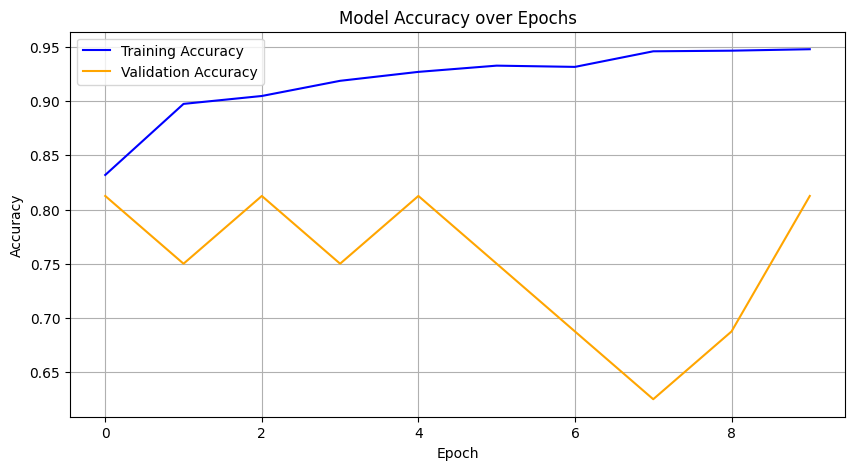

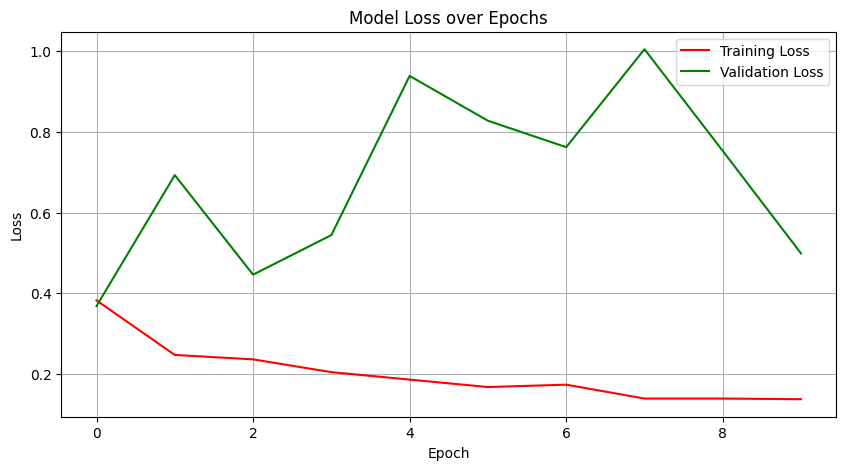

In [6]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Model Accuracy over Epochs')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)
plt.show()
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss', color='red')
plt.plot(history.history['val_loss'], label='Validation Loss', color='green')
plt.title('Model Loss over Epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)
plt.show()